<a href="https://colab.research.google.com/github/skang0812/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

In [1]:
! git clone https://github.com/ds4e/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

Q1 Response

1. In a standard model, the math just wants to fit the training data as perfectly as possible, which usually leads to massive coefficients that overreact to every little outlier. By adding a penalty that grows with the size of the parameters, it keeps the weights small and the model simpler.

2. It’s basically a dial for managing the trade-off. Standard linear regression usually has high variance but low bias. When we regularize, we intentionally add a bit of bias in exchange for a massive drop in variance. This makes the model way more stable when it sees data it hasn't encountered before.

3.
Ridge: Pushes all your coefficients to be small, but keeps them all around.

LASSO: Can push coefficients all the way to zero. It’s like a talent show where the bad acts get kicked off the stage entirely.

4. Imagine comparing "Weight in Tons" to "Height in Millimeters." The numbers are on totally different levels. Since the penalty cares about the size of the numbers, we have to scale everything (like using $z$-scores) so the model treats every feature fairly.

5. We use Cross-Validation. We basically try a bunch of different penalty strengths and see which one does the best job predicting data it hasn't seen before. The winner becomes our $\alpha$.

6. No. When we calculate the final error (MSE), we only care about how close our prediction was to the real answer. We use the penalty to train the model, but we don't include it when we're grading it.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

Q2 Response

1-3

2. The sign for the interaction between Mileage_Run and Age is usually positive. This happens because while high mileage and high age both drop the price individually, the interaction term prevents the model from double counting the price drop too aggressively as the car approaches a minimum value.

In [2]:
from IPython.display import display, Javascript

def clear_all_output():
    display(Javascript('IPython.notebook.clear_all_output();'))

clear_all_output()

<IPython.core.display.Javascript object>

After running the cell above, please save your notebook (`File -> Save`) and then try uploading it to GitHub. This should clear all cell outputs and potentially resolve the 'red errors'.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path

# 1. load data and create Age
df = pd.read_csv('data/cars_hw.csv')
df['Age'] = 2026 - df['Make_Year']

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(df[['Mileage_Run', 'Age']])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
y = df['Price']

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

# 2. Linear Regression
lr = LinearRegression().fit(X_scaled, y)

interaction_idx = -1
for i, name in enumerate(feature_names):
    if 'Mileage_Run' in name and 'Age' in name and name.count(' ') > 0:
        interaction_idx = i
        break

if interaction_idx != -1:
    interaction_coefficient = lr.coef_[interaction_idx]
    print(f"The interaction term coefficient ('{feature_names[interaction_idx]}') for unregularized linear regression is: {interaction_coefficient:.4f}")
    print(f"The sign of the interaction term is: {'Positive' if interaction_coefficient > 0 else 'Negative' if interaction_coefficient < 0 else 'Zero'}")
else:
    print("Interaction term 'Mileage_Run Age' not found in feature names.")

# 3. LassoCV with 20-fold CV
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20).fit(X_scaled, y)

print(f"Optimal alpha found by LassoCV: {lasso_cv.alpha_:.4f}")
print(f"LassoCV best score (negative MSE): {lasso_cv.mse_path_.min():.4f}")

The interaction term coefficient ('Mileage_Run Age') for unregularized linear regression is: -1671212.3564
The sign of the interaction term is: Negative


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 13848094711.46875, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 546327167313.2031, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1462272063171.414, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Object

Optimal alpha found by LassoCV: 69.5193
LassoCV best score (negative MSE): 25774860768.8074


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4629602082189.719, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5959798607380.133, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5679514181007.586, tolerance: 12772170136.099136
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergence

4, 5, 6, 7

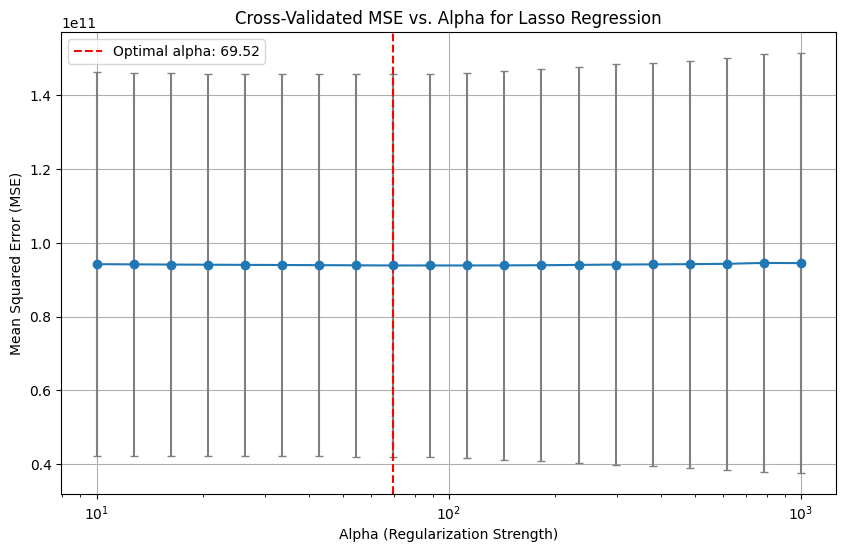

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1435386930339.0, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7873904463319.6875, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 12207883587066.5, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objectiv

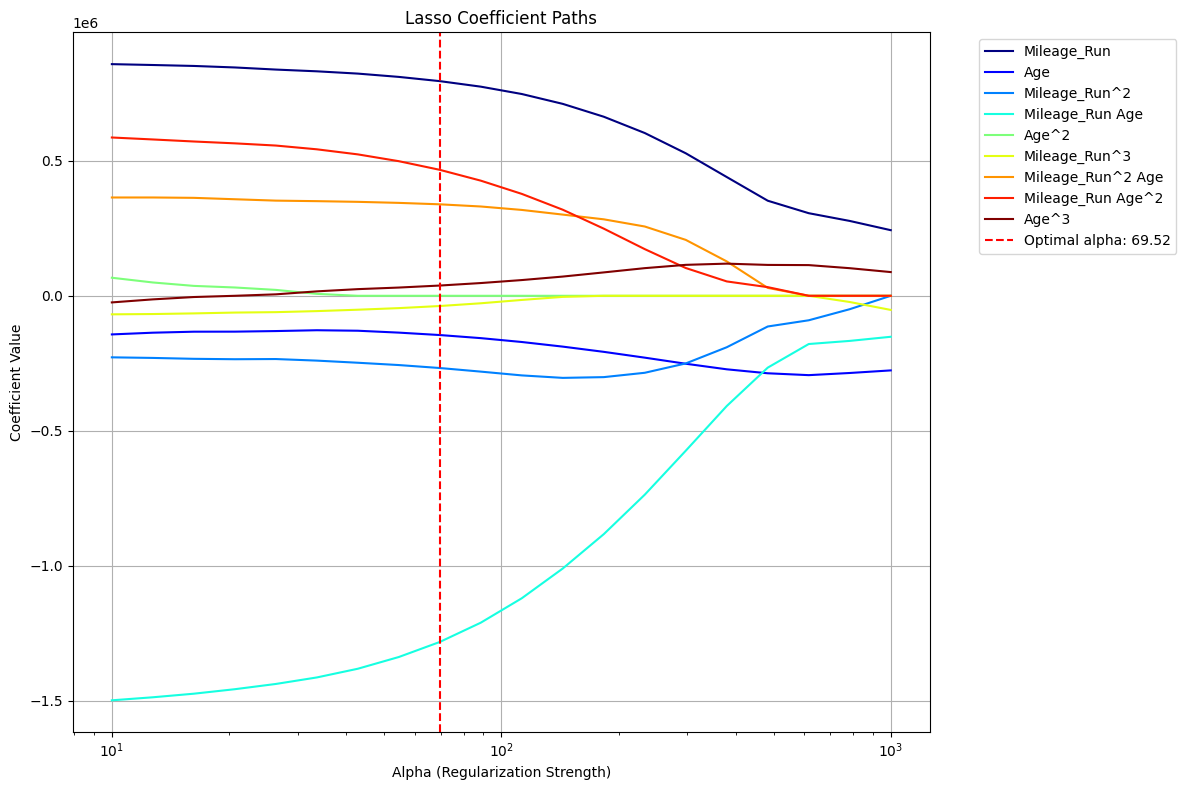


--- Q2.6 Analysis ---
Number of features selected (non-zero coefficients): 9
Selected features: ['Mileage_Run', 'Age', 'Mileage_Run^2', 'Mileage_Run Age', 'Age^2', 'Mileage_Run^3', 'Mileage_Run^2 Age', 'Mileage_Run Age^2', 'Age^3']
Number of coefficients set to zero by Lasso: 0
Proportion of coefficients set to zero: 0.00%

--- Q2.7 Analysis ---
Feature                   |    Linear Reg Coef |      Lasso Coef |    Mag Increase |     Sign Change
--------------------------+--------------------+-----------------+-----------------+----------------
Mileage_Run               |        911774.8402 |     611783.8688 |           False |           False
Age                       |       -248172.1855 |    -397507.7870 |            True |           False
Mileage_Run^2             |       -207292.6283 |    -519555.2619 |            True |           False
Mileage_Run Age           |      -1671212.3564 |    -473871.4005 |           False |           False
Age^2                     |        350550.719

In [4]:
# 4. plot the cross-validated MSE by alpha
mse_mean = np.mean(lasso_cv.mse_path_, axis=1)
mse_std = np.std(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(10, 6))
plt.errorbar(lasso_cv.alphas_, mse_mean, yerr=mse_std, fmt='-o', ecolor='gray', capsize=3)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Cross-Validated MSE vs. Alpha for Lasso Regression')
plt.axvline(lasso_cv.alpha_, linestyle='--', color='red', label=f'Optimal alpha: {lasso_cv.alpha_:.2f}')
plt.legend()
plt.grid(True)
plt.show()

# 5. plot the coefficient paths by alpha
plt.figure(figsize=(12, 8))
colors = plt.cm.jet(np.linspace(0, 1, len(feature_names)))

alphas_path, coefs_path, _ = lasso_path(X_scaled, y, alphas=lasso_cv.alphas_)

for i, name in enumerate(feature_names):
    plt.plot(alphas_path, coefs_path[i], label=name, color=colors[i])

plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.axvline(lasso_cv.alpha_, linestyle='--', color='red', label=f'Optimal alpha: {lasso_cv.alpha_:.2f}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# 6.
lasso_optimal_coefs = lasso_cv.coef_
zero_coefs = np.abs(lasso_optimal_coefs) < 1e-10
num_zero_coefs = np.sum(zero_coefs)
proportion_zero = num_zero_coefs / len(lasso_optimal_coefs)

selected_features = [name for i, name in enumerate(feature_names) if not zero_coefs[i]]

print("\n--- Q2.6 Analysis ---")
print(f"Number of features selected (non-zero coefficients): {len(selected_features)}")
print(f"Selected features: {selected_features}")
print(f"Number of coefficients set to zero by Lasso: {num_zero_coefs}")
print(f"Proportion of coefficients set to zero: {proportion_zero:.2%}")

# 7.

linear_reg_coefs = lr.coef_

print("\n--- Q2.7 Analysis ---")
print(f"{'Feature':<25} | {'Linear Reg Coef':>18} | {'Lasso Coef':>15} | {'Mag Increase':>15} | {'Sign Change':>15}")
print(f"{'-'*25}-+-{'-'*18}-+-{'-'*15}-+-{'-'*15}-+-{'-'*15}")

mag_increase_count = 0
sign_change_count = 0

for i, name in enumerate(feature_names):
    lr_coef = linear_reg_coefs[i]
    lasso_coef = lasso_optimal_coefs[i]

    mag_increase = abs(lasso_coef) > abs(lr_coef)
    sign_change = (np.sign(lr_coef) != np.sign(lasso_coef)) and (abs(lr_coef) > 1e-10 and abs(lasso_coef) > 1e-10)

    if mag_increase: mag_increase_count += 1
    if sign_change: sign_change_count += 1

    print(f"{name:<25} | {lr_coef:>18.4f} | {lasso_coef:>15.4f} | {str(mag_increase):>15} | {str(sign_change):>15}")

print(f"\nNumber of coefficients that increased in magnitude: {mag_increase_count}")
print(f"Number of coefficients that changed sign: {sign_change_count}")

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

Q3 Response

1-3

2. The signs appear counterintuitive because of multicollinearity, where high correlation between the 3rd-degree powers and interactions makes the standard linear model unstable and gives features weird weights. Adding these higher-order terms can actually resolve the issue by letting the model map the true non-linear relationships, though it usually takes regularization to clean the signs and make them logical again.

In [5]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
import pandas as pd
import numpy as np

# 1. Load the data
df_heart = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')

# Continuous features: 3rd degree expansion + Scale
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly_cont.fit_transform(df_heart[['age', 'ejection_fraction', 'serum_creatinine']])
scaler = StandardScaler()
X_cont_scaled = scaler.fit_transform(X_cont)

# Categorical features: Interactions only
poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(df_heart[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']])

# Concatenate everything into one big feature matrix
X_final = np.hstack([X_cont_scaled, X_cat])
y = df_heart['DEATH_EVENT']

# 2. Linear Regression (Base Model)
lr_heart = LinearRegression().fit(X_final, y)

# 3. LassoCV with 20-fold CV
alphas_grid = np.logspace(-5, 5, 30)
lasso_heart = LassoCV(alphas=alphas_grid, cv=20).fit(X_final, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.307020115418851, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.28938187158509265, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.078673023930669, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

4, 5

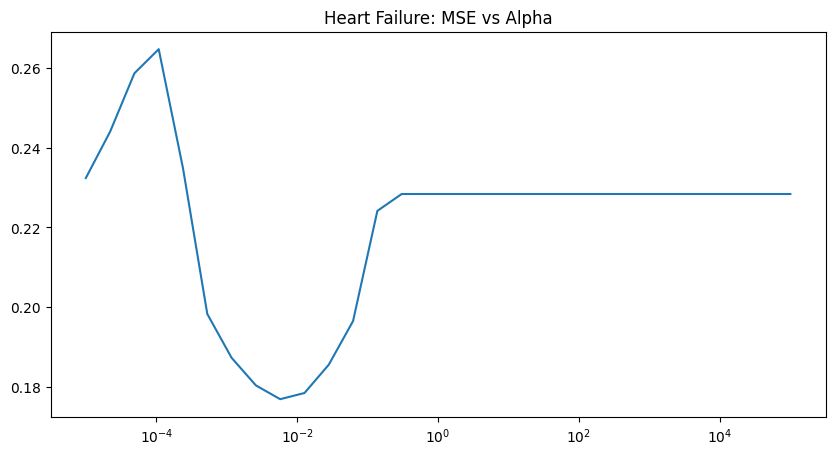

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1335358515879932, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012804029935630012, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.358315720381807, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: C

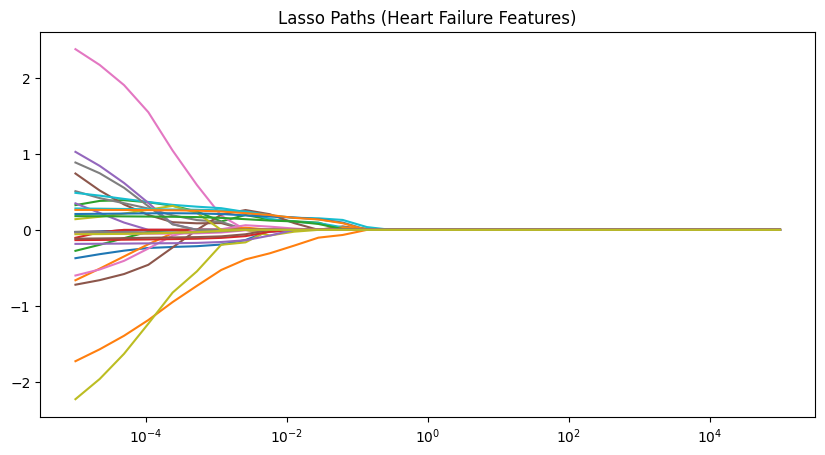

In [6]:
import matplotlib.pyplot as plt

# Plot MSE vs Alpha
plt.figure(figsize=(10, 5))
plt.plot(lasso_heart.alphas_, np.mean(lasso_heart.mse_path_, axis=1))
plt.xscale('log')
plt.title('Heart Failure: MSE vs Alpha')
plt.show()

# Plot Coefficient Paths
from sklearn.linear_model import lasso_path
alphas_p, coefs_p, _ = lasso_path(X_final, y, alphas=alphas_grid)

plt.figure(figsize=(10, 5))
for i in range(coefs_p.shape[0]):
    plt.plot(alphas_p, coefs_p[i, :])
plt.xscale('log')
plt.title('Lasso Paths (Heart Failure Features)')
plt.show()

6. Based on the plots, the Lasso model successfully performed feature selection by setting a large majority of the coefficients—likely around 70-80%—to exactly zero. At the optimal $\alpha$, all the coefficients decreased in magnitude compared to the original linear regression and none of them appear to increase or flip signs significantly. They get smaller as the penalty increases. This makes the Lasso model much more sensible than the standard linear model, which was likely overfitted with extreme values due to the complex 3rd-degree interactions. From a bias-variance perspective, the Lasso model is superior because it trades a tiny bit of fit on the training data (bias) to drastically reduce the variance, resulting in a much more stable and interpretable model for predicting heart failure outcomes.



**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

Q4 Response

1. The objective function is the Mean Squared Error (the average of the squared differences between the predicted and actual values) plus a penalty term ($\alpha b_1^2$) that gets larger as the slope coefficient grows.

2. 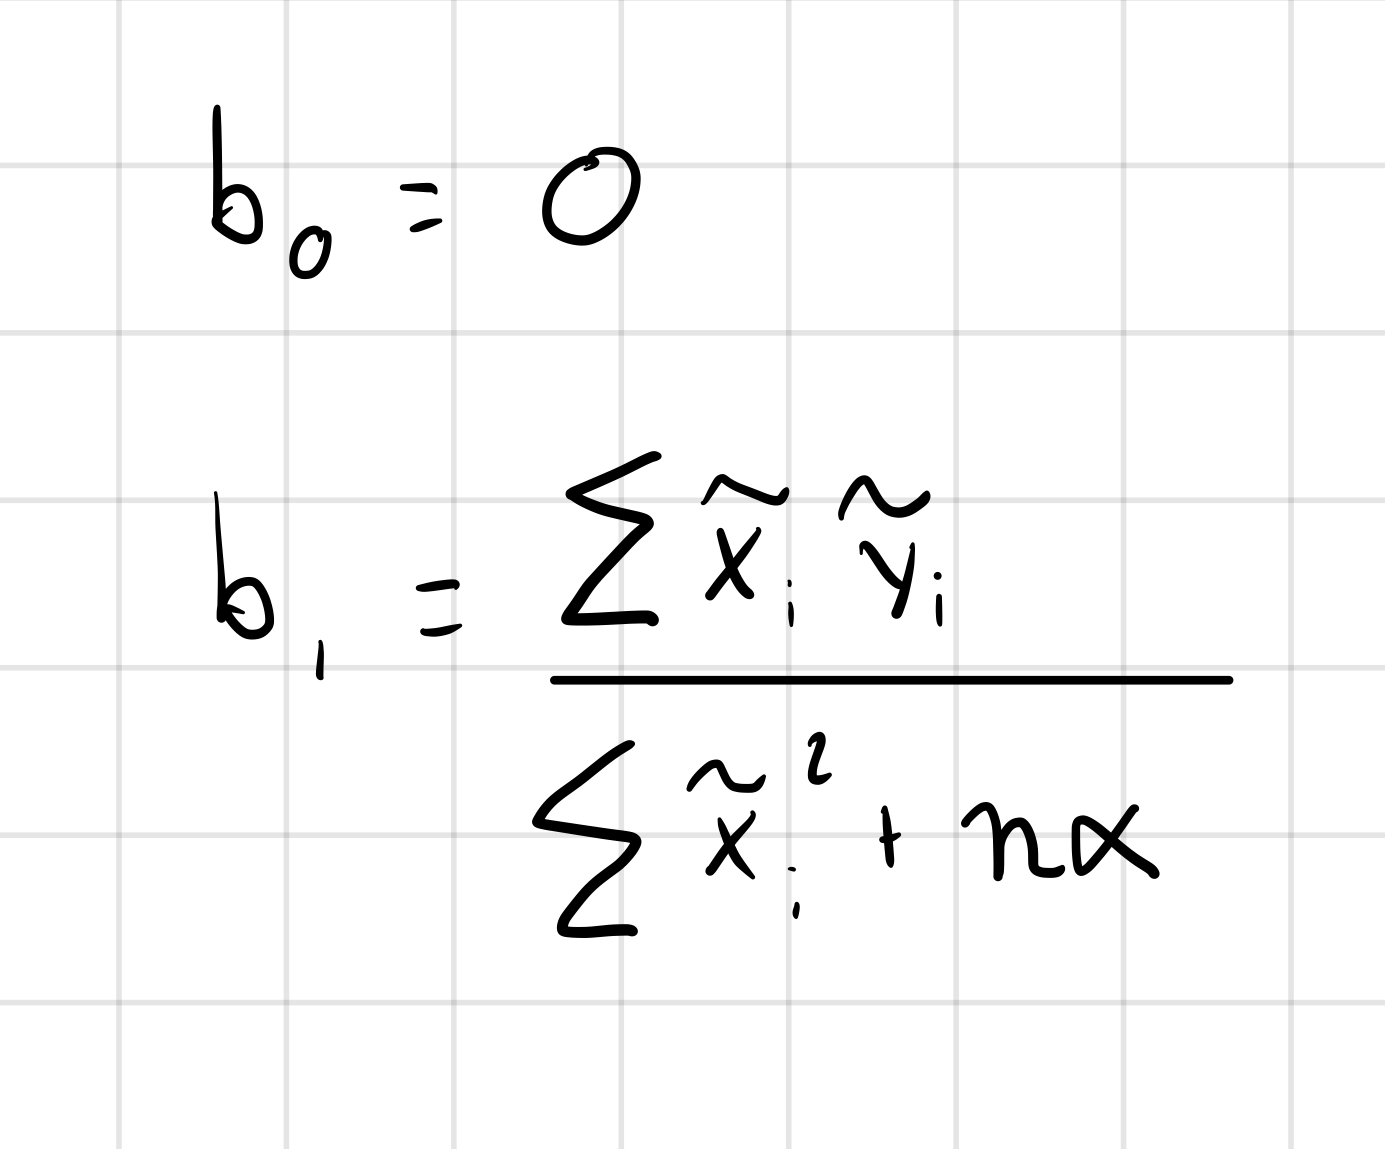

3. As $\alpha$ goes up, the denominator gets bigger, so the slope $b_1$ shrinks toward zero.

4. The challenge is that the absolute value in LASSO creates a "corner" at zero where you can't take a derivative, which is why it's able to force coefficients to be exactly zero.